In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("streetlight.csv")
df.head()

,Geo Point,Geo Shape,prop_id,name,addresspt1,xorg,ext_id,asset_clas,label,asset_type,...,northing,str_id,addresspt_,asset_subt,xsource,profile,xdate,xdrawing,mcc_id,roadseg_id
0,"-37.81373899955726, 144.9421289998664","{""coordinates"": [144.9421289998664, -37.813738...",0,NaN,0.0,ESG,210,NaN,6.549,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
1,"-37.813802999768036, 144.94222000027733","{""coordinates"": [144.94222000027733, -37.81380...",0,NaN,0.0,ESG,251,NaN,54.448,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
2,"-37.81351900001735, 144.94179300024945","{""coordinates"": [144.94179300024945, -37.81351...",0,NaN,0.0,ESG,77,NaN,18.280,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
3,"-37.813650000163264, 144.94197300048748","{""coordinates"": [144.94197300048748, -37.81365...",0,NaN,0.0,ESG,153,NaN,9.580,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
4,"-37.81365800034834, 144.94198700021394","{""coordinates"": [144.94198700021394, -37.81365...",0,NaN,0.0,ESG,159,NaN,27.370,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0


In [9]:
print("Streetlight dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Streetlight dataset shape: (106037, 21)

Columns:
['Geo Point', 'Geo Shape', 'prop_id', 'name', 'addresspt1', 'xorg', 'ext_id', 'asset_clas', 'label', 'asset_type', 'easting', 'northing', 'str_id', 'addresspt_', 'asset_subt', 'xsource', 'profile', 'xdate', 'xdrawing', 'mcc_id', 'roadseg_id']

Missing values:
Geo Point          0
Geo Shape          0
prop_id            0
name          106037
addresspt1         0
xorg               0
ext_id             0
asset_clas    106037
label              0
asset_type    106037
easting            0
northing           0
str_id             0
addresspt_         0
asset_subt    106037
xsource       106037
profile       106037
xdate              0
xdrawing      106037
mcc_id             0
roadseg_id         0
dtype: int64


In [11]:
df[['latitude', 'longitude']] = df['Geo Point'].str.split(',', expand=True)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df[['Geo Point', 'latitude', 'longitude']].head()

,Geo Point,latitude,longitude
0,"-37.81373899955726, 144.9421289998664",-37.813739,144.942129
1,"-37.813802999768036, 144.94222000027733",-37.813803,144.942220
2,"-37.81351900001735, 144.94179300024945",-37.813519,144.941793
3,"-37.813650000163264, 144.94197300048748",-37.813650,144.941973
4,"-37.81365800034834, 144.94198700021394",-37.813658,144.941987


In [12]:
streetlights_clean = df.dropna(subset=['latitude', 'longitude']).copy()
print("Cleaned streetlight dataset shape:", streetlights_clean.shape)

Cleaned streetlight dataset shape: (106037, 23)


In [14]:
print("Total streetlights:", len(streetlights_clean))
print("Unique road segment IDs:", streetlights_clean['roadseg_id'].nunique())
print("Unique external IDs:", streetlights_clean['ext_id'].nunique())

Total streetlights: 106037
Unique road segment IDs: 1
Unique external IDs: 106037


In [15]:
streetlights_clean['label'].describe()

count    106037.000000
mean         15.044992
std          20.792836
min           0.000000
25%           1.857000
50%           6.745000
75%          18.671000
max          99.316000
Name: label, dtype: float64

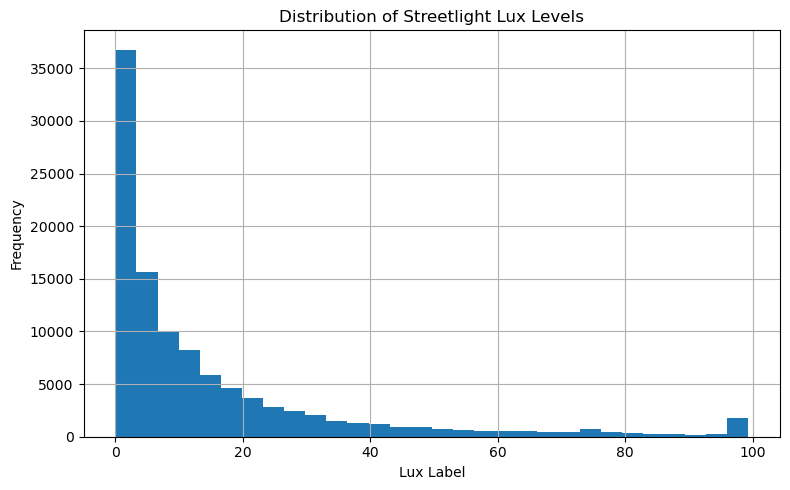

In [18]:
import os
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)
plt.figure(figsize=(8,5))
streetlights_clean['label'].dropna().hist(bins=30)
plt.title("Distribution of Streetlight Lux Levels")
plt.xlabel("Lux Label")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/streetlight.png")
plt.show()

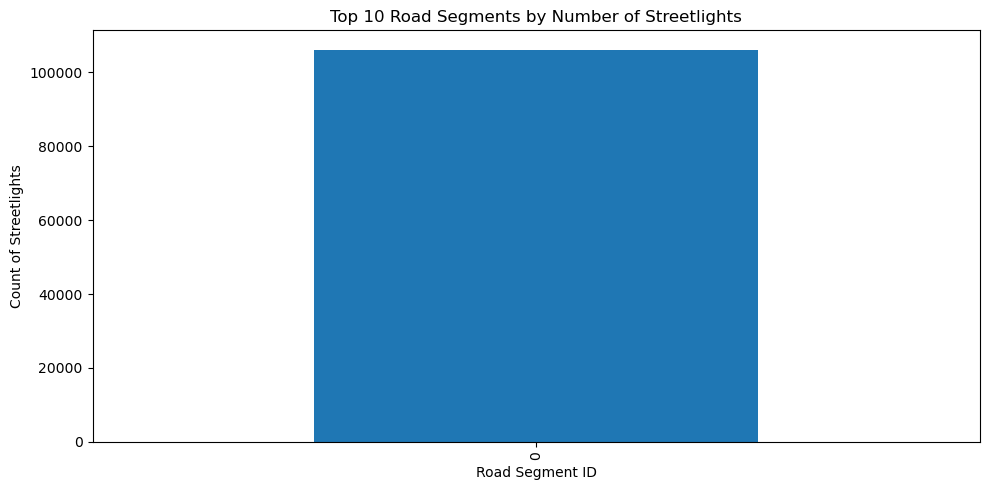

In [19]:
top_segments = streetlights_clean['roadseg_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_segments.plot(kind='bar')
plt.title("Top 10 Road Segments by Number of Streetlights")
plt.xlabel("Road Segment ID")
plt.ylabel("Count of Streetlights")
plt.tight_layout()
plt.show()